# Extended Kalman filtering and smoothing

**Reza Sameni**  
Emory University

State estimation from noisy and missing epidemic observations.

## Topics

- Compare prior, filtered, and smoothed estimates.
- Verify that missing observations skip correction.
- Estimate susceptible, infected, and contact-rate states.

**Run:** install the package with `python -m pip install -e ".[notebooks,dev]"`, then run all cells in order. All numerical functions are imported from `src/epidemic_modeling`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, HTML
import epidemic_modeling as em
from epidemic_modeling.plotting import (
    configure_plots,
    repository_root,
    plot_compartments,
    plot_growth,
)

root = repository_root()
configure_plots()
print(f"epidemic_modeling {em.__version__} · local data")


epidemic_modeling 2.0.0 · local data


## Two-state exponential model

The state is $[c,\lambda]^\mathsf{T}$. Cases evolve as $c_{k+1}=c_k e^{\Delta\lambda_k}+w_1$, while growth uses a saturating tanh update. The EKF linearizes these equations. The fixed-interval smoother uses the entire interval and is therefore retrospective.

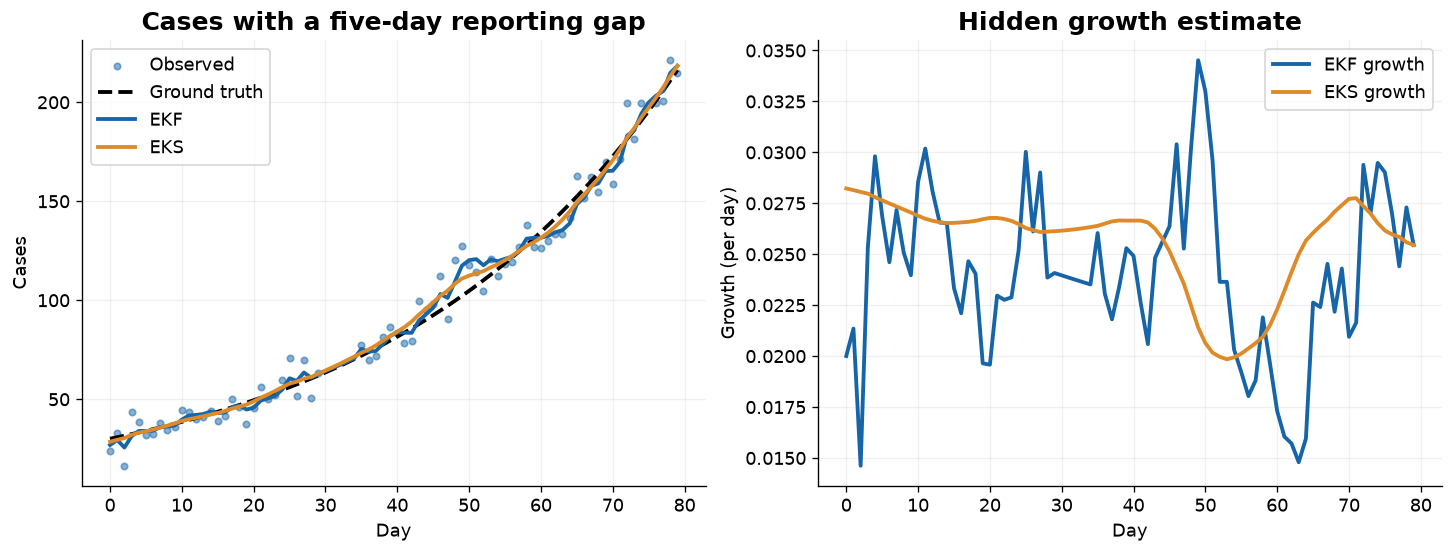

In [2]:
day = np.arange(80)
truth = 30 * np.exp(0.025 * day)
rng = np.random.default_rng(2026)
observed = truth + 8 * rng.standard_normal(len(day))
observed[30:35] = np.nan
result = em.rt_exp_fit_ekf(
    observed,
    [30, 0.02],
    [1, 1, 0.2],
    [0, 0],
    0,
    np.diag([64, 0.001]),
    np.diag([4, 1e-5]),
    64,
    1,
    1,
    14,
    1,
)
s_minus, s_plus, p_minus, p_plus, gain, s_smooth, p_smooth, innovations, rho = result
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(day, observed, s=15, alpha=0.5, label="Observed")
axes[0].plot(day, truth, color="black", linestyle="--", label="Ground truth")
axes[0].plot(day, s_plus[0], label="EKF")
axes[0].plot(day, s_smooth[0], label="EKS")
axes[1].plot(day, s_plus[1], label="EKF growth")
axes[1].plot(day, s_smooth[1], label="EKS growth")
axes[0].set(title="Cases with a five-day reporting gap", xlabel="Day", ylabel="Cases")
axes[1].set(title="Hidden growth estimate", xlabel="Day", ylabel="Growth (per day)")
for ax in axes:
    ax.legend()
plt.show()
assert np.all(gain[:, :, 30:35] == 0)
assert np.allclose(s_plus[:, 30:35], s_minus[:, 30:35])


## SI-alpha state estimation

The second model estimates normalized susceptible and infected fractions and a contact rate. `NEWCASES` observes the product $s i \alpha$; `TOTALCASES` observes $1-s$. These observations constrain the states differently.

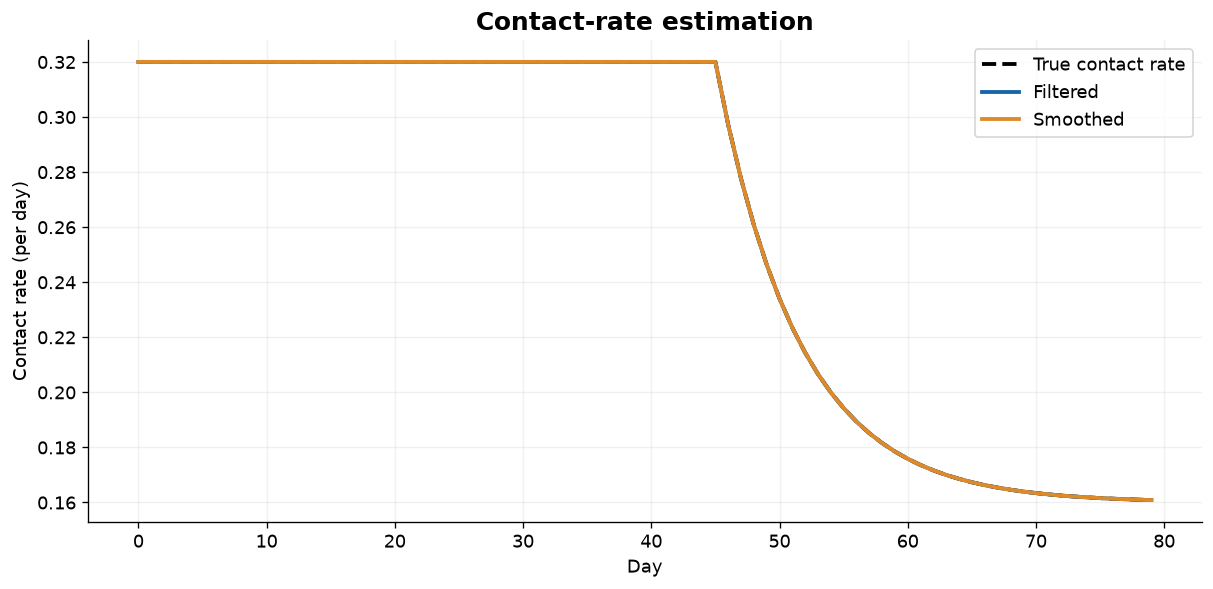

In [3]:
params = em.default_si_params([3])
params.update(a=np.array([0.08]), b=0.08)
u = np.r_[np.zeros(45), np.full(35, 2.0)][None, :]
state = [0.999, 0.001, 0.32]
trajectory = np.array(
    em.si_alpha_controlled(
        u,
        *state,
        params["u_max"],
        0,
        5,
        params["gamma"],
        params["a"],
        params["b"],
        params["beta"],
        0,
        0,
        0,
        len(day),
        1,
        noise=np.zeros((3, len(day)))
    )
)
before = np.column_stack((state, trajectory[:, :-1]))
incidence = np.prod(before, axis=0)
estimated = em.si_alpha_model_ekf(
    u,
    incidence,
    params,
    state,
    np.diag([1e-7, 1e-7, 0.01]),
    np.full(3, np.nan),
    np.full((3, 3), np.nan),
    np.zeros(3),
    0,
    np.diag([1e-9, 1e-9, 1e-5]),
    1e-10,
)
fig, ax = plt.subplots()
ax.plot(day, before[2], color="black", linestyle="--", label="True contact rate")
ax.plot(day, estimated.s_plus[2], label="Filtered")
ax.plot(day, estimated.s_smooth[2], label="Smoothed")
ax.set(title="Contact-rate estimation", xlabel="Day", ylabel="Contact rate (per day)")
ax.legend()
plt.show()


## Further experiments

- Increase process noise for contact rate and compare responsiveness.
- Compare `order=1` and `order=2` in the exponential filter.
- Explain why SI-alpha `order=2` returns the same corrections as `order=1`: its inherited Hessian callbacks return zero.
- Inspect `rho`, the normalized innovation covariance monitor.

**Paired MATLAB example:** `demo_kalman_estimation`.

## References and next steps

1. Reza Sameni (2020). *Mathematical Modeling of Epidemic Diseases; A Case Study of the COVID-19 Coronavirus*. [arXiv:2003.11371](https://arxiv.org/abs/2003.11371).
2. Reza Sameni (2022). *Model-Based Prediction and Optimal Control of Pandemics by Non-Pharmaceutical Interventions*. IEEE JSTSP, **16**(2), 307–317. [DOI:10.1109/JSTSP.2021.3129118](https://doi.org/10.1109/JSTSP.2021.3129118).

Equations and existing research images originate from the cited work and the [original repository](https://github.com/alphanumericslab/EpidemicModeling). Consult `docs/api.md` for array shapes and `docs/migration.md` for deliberate fixes.